# Deep Research Arena — 接地(Grounding)差异深度分析

**日期:2026-06-09 · 数据:本仓库 `data/results/`(deep_v3 框架矩阵 433 个评分文件、模型榜 `leaderboard_models_v3.json`、2026-04-16 ReAct 跨模型 bench、ERROR_TAXONOMY)**

## 一句话总结

**接地高低不取决于搜索接入(所有框架都正确接入了沙盒 search shim,搜到的都是真 URL),而取决于"真实 URL 能否以逐字形式存活到最终写报告的那次 LLM 调用的上下文里"。** 凡是工具观测和写作在同一上下文的框架,接地就高;凡是中间经过 embedding/摘要/跨 agent 交接的框架,URL 被丢弃,writer 只能凭参数知识"再生成"参考文献,接地就崩。模型层面同理:在证据完全相同的极简脚手架下,写作越流畅的模型(qwen3-max、deepseek-v4-flash)越倾向编 URL 补全报告,判官 Elo 与接地呈负相关。

评测环境背景:沙盒 = Magento 商城(`localhost:7770`)+ Postmill 论坛(`localhost:9999`)+ Kiwix 维基(`localhost:8090`),统一 backbone deepseek-v4-flash(ds_proxy:8088),搜索经 Tavily 兼容 shim 翻译为沙盒内检索,**返回的全部是真实沙盒 URL**。真实 URL 形态:商品 `7770/<长slug>(.html)`、论坛 `9999/f/<forum>/<id>/<slug>`、维基 `8090/content/wikipedia_en_all_nopic/A/<Title>`。

In [1]:
import json, glob, os, re, collections
import pandas as pd
import matplotlib.pyplot as plt

ROOT = '/root/Desktop/lyb/deep_reserch'
RES  = os.path.join(ROOT, 'data/results')
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Droid Sans Fallback', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
print('score files:', len(glob.glob(f'{RES}/deep_v3/*_matrix.score.json')))

score files: 349


## 第一部分:框架层分析

### 1.1 各框架接地总表

从 `deep_v3/*_matrix.score.json` 全量聚合。列说明:`reach` = 引用 URL 可达率(HTTP 200 / 已探测);`cited` = 平均引用 URL 数;`offSB` = 引用沙盒外(外网)URL 数;`deadURL` = 4xx/5xx/网络失败数;`quote` = 引文与被引页面文本的匹配率;`citePrec` = 句子级引用精确率(LLM 判官);`chars` = 报告长度。

In [2]:
rows = []
for f in sorted(glob.glob(f'{RES}/deep_v3/*_matrix.score.json')):
    try:
        d = json.load(open(f))
    except Exception:
        continue
    agent = os.path.basename(f).split('__')[0]
    ur  = d.get('url_reachability', {});  urd = ur.get('details', {})
    uc  = d.get('url_coverage', {});      ucd = uc.get('details', {})
    rows.append(dict(
        agent=agent,
        task=d.get('task',''),
        reach=ur.get('score', 0) or 0,
        cited=urd.get('cited_total', 0),
        offSB=urd.get('cited_off_sandbox', 0),
        deadURL=urd.get('http_4xx', 0) + urd.get('http_5xx', 0) + urd.get('net_fail', 0),
        http200=urd.get('http_200', 0),
        urlcov=uc.get('score', 0) or 0,
        must_recall=ucd.get('must_cite_recall', 0) or 0,
        quote=d.get('quote_match', {}).get('score', 0) or 0,
        citePrec=(d.get('citation_alignment', {}).get('details', {}) or {}).get('citation_precision', 0) or 0,
        chars=d.get('answer_chars', 0),
    ))
df = pd.DataFrame(rows)
frame = (df.groupby('agent')
           .agg(n=('reach','size'), reach=('reach','mean'), cited=('cited','mean'),
                offSB=('offSB','mean'), deadURL=('deadURL','mean'), urlcov=('urlcov','mean'),
                quote=('quote','mean'), citePrec=('citePrec','mean'), chars=('chars','mean'))
           .sort_values('reach', ascending=False))
frame

,n,reach,cited,offSB,deadURL,urlcov,quote,citePrec,chars
agent,,,,,,,,,
claude-code,5,0.965,113.600,0.000,4.200,0.273,0.860,0.651,"50,629.000"
camel-ai,56,0.905,56.286,0.089,4.839,0.137,0.780,0.600,"29,210.411"
smolagents,30,0.713,46.567,1.500,9.633,0.117,0.634,0.416,"15,902.733"
ldr,30,0.650,2.233,0.000,0.233,0.007,0.000,0.000,"1,670.733"
flowsearcher-ds,48,0.497,32.854,0.021,7.875,0.060,0.454,0.319,"19,426.229"
deerflow,30,0.155,13.533,10.733,1.100,0.006,0.017,0.000,"24,108.867"
gpt-researcher,30,0.031,62.333,1.467,59.333,0.191,0.001,0.000,"25,740.500"
langchain-odr,30,0.004,41.567,8.033,33.167,0.071,0.001,0.000,"26,951.333"
ii-researcher,30,0.002,13.167,0.933,12.033,0.031,0.001,0.000,"5,657.633"


**读表**:三个清晰的层级。claude-code / camel-ai 可达率 0.90+ 且引用量大、引文核实率高;smolagents / ldr / flowsearcher-ds 居中但病因各不相同(下文逐个分析);deerflow / gpt-researcher / langchain-odr / ii-researcher 接近全编;storm / qx-agents 完全退化(报告只有一两百字符,是 harness 故障不是框架能力,见 1.5)。

注意两组对比鲜明的指纹:**gpt-researcher 引了 62 个 URL 其中 59 个死链**(域名对、路径全编),而 **deerflow 的失败表现为 offSB=10.7**(把 localhost 引用替换成 en.wikipedia.org / amazon.com 等真实外网 URL)。这两种失败模式来源不同,后面用 URL 形态统计验证。

### 1.2 逐任务可达率分布:接地失败是"整篇崩",不是均匀衰减

如果编造是随机噪声,可达率应集中在中间;实际上大多数框架呈双峰:一篇报告要么 URL 全真(写作时上下文里有 URL 可抄),要么全假(上下文丢了,整篇参考文献都是再生成的)。smolagents 是典型双峰;camel-ai 的少量失败也是个别任务整篇崩(上下文截断)。

In [3]:
dist = (df.assign(bucket=pd.cut(df.reach, [-0.01, 0.1, 0.5, 0.9, 1.01],
                                labels=['崩(≤0.1)', '低(0.1–0.5]', '中(0.5–0.9]', '高(>0.9)']))
          .pivot_table(index='agent', columns='bucket', values='task', aggfunc='size', fill_value=0, observed=False))
dist['n'] = dist.sum(axis=1)
dist = dist.loc[frame.index]   # 按可达率排序
dist

bucket,崩(≤0.1),低(0.1–0.5],中(0.5–0.9],高(>0.9),n
agent,,,,,
claude-code,0,0,0,5,5
camel-ai,1,1,15,39,56
smolagents,4,4,6,16,30
ldr,10,1,0,19,30
flowsearcher-ds,18,5,12,13,48
deerflow,22,3,4,1,30
gpt-researcher,27,3,0,0,30
langchain-odr,30,0,0,0,30
ii-researcher,30,0,0,0,30


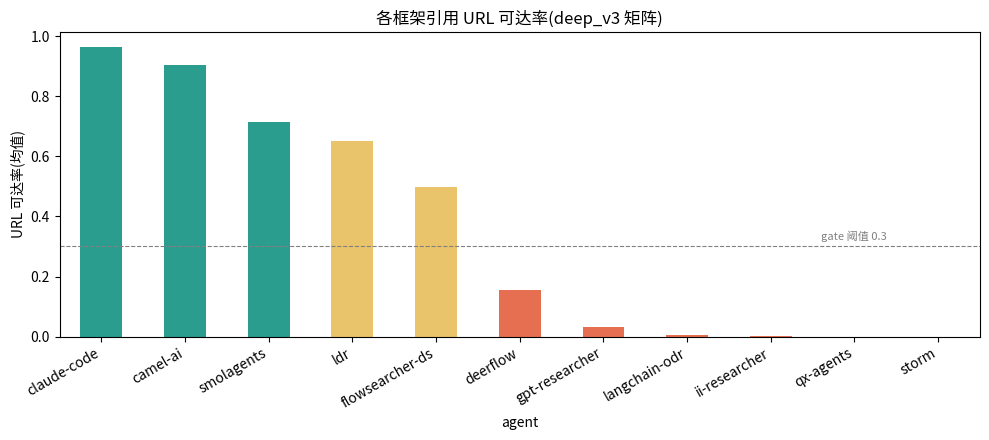

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
frame['reach'].plot.bar(ax=ax, color=['#2a9d8f' if v >= 0.7 else '#e9c46a' if v >= 0.3 else '#e76f51' for v in frame['reach']])
ax.set_ylabel('URL 可达率(均值)'); ax.set_title('各框架引用 URL 可达率(deep_v3 矩阵)')
ax.axhline(0.3, ls='--', c='gray', lw=0.8); ax.text(8.6, 0.32, 'gate 阈值 0.3', fontsize=8, c='gray')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

### 1.3 编造 URL 的三种指纹(形态统计)

对每个框架的引用 URL 做模式分类(URL 取自可用的报告原文 `data/results/deep/*.md`,缺失时回退到 score JSON 里的探测样本;启发式规则,用于定性):

- **`fab_products`**:`7770/products/<slug>` 或 `7770/product/<slug>`。真实 Magento 路径没有这种 REST 前缀。这是 **gpt-researcher / langchain-odr 的"理想化 REST 路径"指纹**:writer 看不到原始 URL,凭产品名拼出干净路径。
- **`fab_wiki`**:`8090/...` 但不含 `/content/wikipedia_en_all_nopic` 前缀(如 `8090/Aperture`)。同源:writer 不知道 Kiwix 的真实路径结构。
- **`fab_forum`**:`9999/...thread-N` / `9999/threads/N` 顺序号编造。
- **`external`**:非 localhost 的外网 URL。**deerflow 的指纹**:reporter 用参数记忆里的真实世界 URL 替换沙盒 URL。
- **`sandbox_other`**:其余 localhost URL(绝大多数为真实长 slug,即从工具结果逐字抄出来的)。

In [5]:
URL_RE = re.compile(r'https?://[^\s\)\]\>"\'\\,]+')

def classify(u):
    u = u.rstrip('.,;:')
    if 'localhost' not in u and '127.0.0.1' not in u:
        return 'external'
    if re.search(r':7770/products?/', u):
        return 'fab_products'
    if ':8090/' in u and '/content/wikipedia' not in u and '/search' not in u:
        return 'fab_wiki'
    if ':9999/' in u and re.search(r'/threads?[-/]\d+', u):
        return 'fab_forum'
    return 'sandbox_other'

fp = collections.defaultdict(collections.Counter)
for f in glob.glob(f'{RES}/deep_v3/*_matrix.score.json'):
    d = json.load(open(f))
    agent = os.path.basename(f).split('__')[0]
    base = os.path.basename(d.get('answer_path', ''))
    report = None
    for cand in (f'{RES}/deep/{base}', f'{RES}/deep_reports/{base}', os.path.join(ROOT, d.get('answer_path',''))):
        if base and os.path.exists(cand):
            report = open(cand, errors='ignore').read(); break
    text = report if report else json.dumps(d)   # 回退:score JSON 里的样本 URL
    for u in set(URL_RE.findall(text)):
        if u.count('/') >= 3:                     # 过滤裸域名
            fp[agent][classify(u)] += 1

fpt = pd.DataFrame(fp).T.fillna(0).astype(int)
fpt = fpt.reindex(columns=['sandbox_other', 'fab_products', 'fab_wiki', 'fab_forum', 'external'], fill_value=0)
fpt['fab_share'] = ((fpt.fab_products + fpt.fab_wiki + fpt.fab_forum + fpt.external)
                    / fpt.sum(axis=1).clip(lower=1)).round(3)
fpt['offSB_mean'] = frame['offSB']   # score 文件实测的沙盒外引用均值(探测器口径,补样本盲区)
fpt.loc[[a for a in frame.index if a in fpt.index]]

,sandbox_other,fab_products,fab_wiki,fab_forum,external,fab_share,offSB_mean
claude-code,558,0,0,0,0,0.000,0.000
camel-ai,1564,94,110,5,52,0.143,0.089
smolagents,740,8,47,0,0,0.069,1.500
ldr,31,0,0,0,0,0.000,0.000
flowsearcher-ds,875,0,0,40,0,0.044,0.021
deerflow,70,0,10,0,0,0.125,10.733
gpt-researcher,375,332,407,55,14,0.683,1.467
langchain-odr,143,108,142,5,123,0.726,8.033
ii-researcher,42,81,17,0,0,0.700,0.933
qx-agents,30,0,0,0,0,0.000,0.000


**读表**:gpt-researcher(fab_share 0.68)、langchain-odr(0.73)、ii-researcher(0.70)的 `fab_products`/`fab_wiki` 占比压倒性,而 claude-code / camel-ai / ldr 几乎全部落在 `sandbox_other`(真实长 slug)。flowsearcher-ds 的编造集中在 `fab_forum`(`thread-003` 式顺序号),对应它"证据注入但截断"的半失真模式。

**注意 deerflow**:它的 `external` 列在此被低估——本机缺它的报告原文,回退用的 score JSON 探测样本只覆盖沙盒 URL,外网引用不进样本。看最右 `offSB_mean` 列(score 文件实测):deerflow 平均每篇 10.7 个沙盒外引用、占其全部引用的 79%,external 替换才是它的主指纹。其余框架两列口径一致,与 1.1 的可达率层级完全互证。

### 1.4 退化运行统计(answer_chars < 500)

零分组的报告根本不是报告,是错误串。下表统计每个框架退化运行占比,并抽样展示退化"报告"的开头。

In [6]:
deg = df[df.chars < 500]
deg_tab = (df.assign(degenerate=df.chars < 500)
             .groupby('agent').degenerate.agg(['sum', 'size', 'mean'])
             .rename(columns={'sum': 'degenerate', 'size': 'n', 'mean': 'share'})
             .sort_values('share', ascending=False))
print(deg_tab.to_string())
print()
for agent in ['storm', 'qx-agents', 'ii-researcher', 'ldr']:
    s = df[df.agent == agent].iloc[0]
    base = None
    for f in glob.glob(f'{RES}/deep/{agent}__*_matrix.md')[:1]:
        base = open(f, errors='ignore').read()[:160].replace(chr(10), ' ')
    print(f'--- {agent}: {base if base else "(报告原文不在本机,仅有 score)"}')

                 degenerate   n  share
agent                                 
storm                    30  30  1.000
qx-agents                30  30  1.000
ii-researcher            23  30  0.767
flowsearcher-ds          18  48  0.375
gpt-researcher            1  30  0.033
camel-ai                  0  56  0.000
claude-code               0   5  0.000
deerflow                  0  30  0.000
langchain-odr             0  30  0.000
ldr                       0  30  0.000
smolagents                0  30  0.000

--- storm: (runner error: OSError: [Errno 36] File name too long: "/opt/deep_reserch/data/results/deep/_storm_scratch/produce_a_causal_explanation_report_answering:_'why_d
--- qx-agents: (报告原文不在本机,仅有 score)
--- ii-researcher: (报告原文不在本机,仅有 score)
--- ldr: (报告原文不在本机,仅有 score)


### 1.5 逐框架机制分析

#### 高接地组:同上下文工具循环

**claude-code(reach 0.965,cited 113.6,quote 0.86)** — SSH 跑 claude CLI,禁用 WebSearch/WebFetch,强制用 Bash `curl` 直接打 shim 和沙盒页面(`scripts/runners/claudecode_runner.py`)。引用全部来自 agent 亲手 curl 过的页面,URL 在上下文里以原文存在,写报告时逐字复制,**没有任何"由 LLM 重新生成参考文献"的环节**。1800s 预算 + 多轮工具循环带来 114 个引用、5 万字符报告。唯一弱点:n=5 样本太少。

**camel-ai(reach 0.905,cited 56.3,quote 0.78)** — 单 ChatAgent + FunctionTool,TavilyClient 被 monkey-patch 指向 shim(`scripts/run_deep_task.py:419-443`)。关键是**工具结果留在同一对话上下文**,`resp.msg.content` 直接成为报告,没有独立 writer 阶段。系统提示的 "Do not invent URLs" 在这种架构下真正生效——模型有真 URL 可抄。少量死链来自长任务下 8192 max_tokens 截断后的尾部失真(0003 任务整篇 `/products/<slug>` 假路径即此,HUMAN_URL_AUDIT 该任务 reach=0%)。

**smolagents(reach 0.713,双峰)** — ToolCallingAgent + VisitWebpageTool,max_steps=60。历史教训:用 CodeAgent 时 92% 的 URL 是代码"构造"出来的,换结构化工具调用(FIX #2)后大幅改善。剩余问题:60 步后写最终答案时早期观测已被滚动截断,模型对部分任务回退到"构造合理 slug"。逐任务双峰(1.2 节表):多数任务 1.0,少数 0.0。提示词约束("NEVER construct or guess URLs")只能压低、不能消除。

#### 中间组:各有独特病因

**ldr(reach 0.650,但只引 2.2 个 URL)** — local-deep-research 本质是轻量摘要器(iterations=2 × questions=2,`scripts/runners/ldr_runner.py`),输出 1.7k 字符短摘要带 2-3 个链接。链接是搜索真实返回的所以基本可达,但有特殊背景:**deepseek-v4-flash 见 localhost URL 触发安全拒答**,runner 被迫把任务意图里的 localhost URL 全部剥掉做消毒(FIX #11/#13),导致它根本不知道任务要求引 60+ 个沙盒 URL。"诚实但极浅"。

**flowsearcher-ds(reach 0.497)** — 自研管线(`scripts/run_flowsearcher.py`):分解 → 搜 shim 收集 URL 池 → **把真实 URL+标题+snippet 列表注入单次 writer prompt**,要求"只用上面的 URL、引 80+"。失真来自:证据文本截到 25k 字符,而产出要求 4000-7000 词 + 80 引用,**指标压力超过证据供给**,模型对截断窗口外的部分近似改写(Kiwix 路径丢 `/A/` 段、论坛 thread 编成 `thread-003`)。另有 18/48 runs 是 runner 捕获失败,拉低均值。

#### 低接地组:writer 与证据分离,系统性编造

**gpt-researcher(reach 0.031,62 引用 59 死链)** — 典型"流畅幻觉者"。搜索接线正确,但 conduct_research 把抓取内容切块进 **embedding 向量库**,write_report 用压缩后的语义 context 写报告,**逐字 URL 在向量化环节被丢弃**。writer 于是发明理想化 REST 路径:`/products/bowflex-selecttech-552`、`/articles/progressive-overload-methods`、顺序号 `/products/1..47`,并掺入真实世界产品名与虚构数据("2,847 reviews")。域名格式全对(offSB 仅 1.5)但路径全编。runner 后来加了"把 visited_urls 回灌 writer"的修复(`scripts/runners/gpt_researcher_runner.py:166-197`),matrix 批次在修复前。

**langchain-odr(reach 0.004)** — langgraph 四段式 supervisor→researcher→compression→writer,三个阶段是**不同的 LLM 调用**,URL 死在 compression 环节。writer 把产品名规范化成干净的发明路径(`7770/product/<slug>` 而真实是 `/<slug>.html`;`8090/Aperture` 而真实要带 `/content/wikipedia_en_all_nopic/A/`)。另一失败模式:部分 run 模型自述"无法访问沙盒服务器",直接闭卷写作("draws on established fitness industry knowledge"),零引用或引外网。

**deerflow(reach 0.155,offSB 10.7)** — planner→researcher→reporter 多 agent。researcher 拿到的是沙盒 URL,但 **reporter 是独立 LLM,写参考文献时用参数记忆里的真实外网 URL(en.wikipedia.org、amazon.com)替换 localhost URL**。指纹是 off-sandbox 而非死链:13.5 个引用里 10.7 个在沙盒外,被 verifier 直接判 "no sandbox-domain URLs cited"。

#### 零分组:harness 故障,不是框架能力

**storm(124 字符)** — 实际跑通了:`data/results/deep/_storm_scratch/` 里存在完整的 4.6k `storm_gen_article_polished.txt`,但 harness 的文章提取逻辑与 scratch 路径错位,22/31 输出字面量 `(empty storm output)`;另有把 300 字符任务意图当目录名导致 `File name too long`。错误被吞(meta.json `error: null`)。

**qx-agents(367 字符)** — 两个独立 runner 级死因:① Windows 评分机上 venv 路径写死 `.venv-qx/bin/python`(Windows 应为 `Scripts\python.exe`),30/30 同一错误串;② rerun 时 openai-agents 的 pydantic 结构化输出校验失败(deepseek 不按 schema 输出),错误文本被当报告。框架从未真正运行。

**ii-researcher(reach 0.002)** — 23/30 是驱动脚本异常,except 分支把 74 字符错误串当报告写盘。7 个成功 run 实际有竞争力(某 rerun 157 个引用全为真实 slug)。约 75% 是 RUNNER 故障,应重跑而非下结论。

> 引用这批结果时必须区分 **AGENT 性低分**(gpt-researcher / langchain-odr / deerflow,应得)与 **RUNNER 性低分**(storm / qx-agents / ii-researcher,需修 harness 重跑)。`docs/FRAMEWORK_ROOT_CAUSE.md` 有同样判定与修复优先级。

## 第二部分:模型层分析

### 2.1 模型榜:同一极简脚手架、只换 backbone(2026-06-08)

8 模型 × 24 任务 × 643 场三判官对战(`scripts/efficiency_experiment.py` 固定协议:模型出 query → shim 搜索抽取 → 模型写报告;搜索轮数固定,**证据输入完全相同**)。数据:`data/results/deep_v3/leaderboard_models_v3.json`。`gated` = 判官 Elo × 可达率(truth-gate 口径)。

In [7]:
mb = json.load(open(f'{RES}/deep_v3/leaderboard_models_v3.json'))
elo, prof = mb['elo_v3_ci'], mb['per_agent_profile']
mrows = []
for k, e in elo.items():
    p = prof.get(k, {})
    mrows.append(dict(model=k.replace('eff-', ''), elo=e['elo'],
                      ci=f"[{e['elo_lo']:.0f},{e['elo_hi']:.0f}]",
                      W=e['wins'], L=e['losses'], D=e['draws'],
                      reach_pct=p.get('reachability_pct'), quote_pct=p.get('url_veracity_pct')))
mdf = pd.DataFrame(mrows).sort_values('elo', ascending=False).reset_index(drop=True)
mdf['gated'] = (mdf.elo * mdf.reach_pct / 100).round(0)
mdf['judge_rank'] = mdf.elo.rank(ascending=False).astype(int)
mdf['gated_rank'] = mdf.gated.rank(ascending=False).astype(int)
print(f"n_tasks={mb['n_tasks']}, n_battles={mb['n_battles']}")
mdf

n_tasks=24, n_battles=643


,model,elo,ci,W,L,D,reach_pct,quote_pct,gated,judge_rank,gated_rank
0,qwen3-max,"1,174.200","[1133,1219]",100,22,39,23.800,17.800,279.000,1,7
1,deepseek-v4-flash,"1,155.900","[1114,1199]",97,24,44,26.400,26.900,305.000,2,5
2,glm-5,"1,013.300","[969,1055]",67,61,37,60.400,57.200,612.000,3,1
3,kimi-k2.5,"1,001.200","[956,1045]",54,54,57,59.800,52.400,599.000,4,2
4,qwen3-30b-a3b-instruct-2507,993.900,"[951,1032]",53,57,51,26.100,21.100,259.000,5,8
5,qwen-flash,928.800,"[886,967]",42,77,43,30.400,23.200,282.000,6,6
6,minimax-m2.5,909.800,"[866,948]",32,72,47,49.000,42.600,446.000,7,3
7,qwen3-32b,823.000,"[772,867]",22,100,34,39.400,34.300,324.000,8,4


判官 Elo vs 可达率:Pearson ρ = -0.361, Spearman ρ = -0.310(n=8,未达显著,方向性参考)


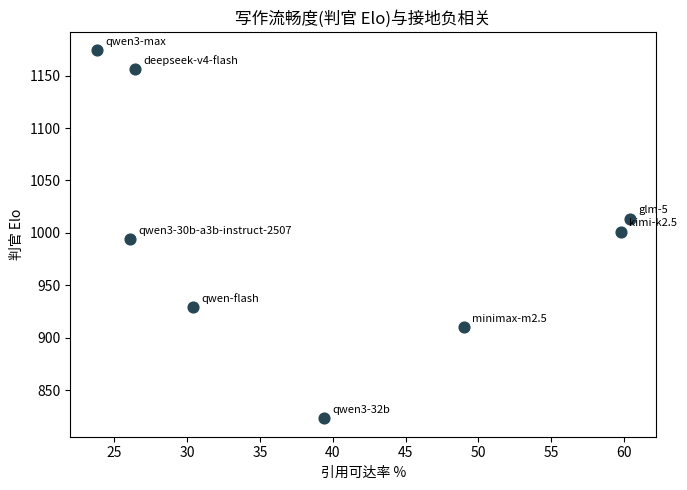

In [8]:
r_p = mdf.elo.corr(mdf.reach_pct, method='pearson')
r_s = mdf.elo.corr(mdf.reach_pct, method='spearman')
print(f'判官 Elo vs 可达率:Pearson ρ = {r_p:.3f}, Spearman ρ = {r_s:.3f}(n=8,未达显著,方向性参考)')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(mdf.reach_pct, mdf.elo, s=60, c='#264653')
for _, r in mdf.iterrows():
    ax.annotate(r.model, (r.reach_pct, r.elo), textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_xlabel('引用可达率 %'); ax.set_ylabel('判官 Elo')
ax.set_title('写作流畅度(判官 Elo)与接地负相关')
plt.tight_layout(); plt.show()

**核心发现:判官 Elo 与接地负相关(n=8 未达显著,但排名反转是实打实的)。**

- **qwen3-max、deepseek-v4-flash:"最会写的编造者"** — 判官前二(1174 / 1156),可达率仅 24-26%。低可达不是没搜到(证据统一喂入),而是写作阶段超出证据编 URL。有记录的具体行为:shim 返回 docker 内部主机名 `wiki:8080` 时,qwen 系照抄或改编成公网假链(`docs/MODEL_X_FRAMEWORK_EXPERIMENT.md`)。当 URL 被直接喂入并要求照抄时 qwen3-max 能做到 reach=1.0——说明**有能力照抄、但自由写作时倾向"补全"引用**,指令遵循是短板,流畅是长板,判官恰好奖励后者。
- **glm-5、kimi-k2.5:"老实人"** — 判官中游(1013 / 1001),可达率 60% 上下、引文核实率 57%/52%,基本只引真拿到的来源。truth-gate 后 glm-5 升至第一。
- **minimax-m2.5** — 写得一般但不太编(reach 49%,gated 升到 #3);但工具调用协议兼容性最差:需特判 `enable_thinking`(HTTP 400 拒参,`scripts/efficiency_experiment.py:76` 注释),4 月 ReAct 批次它是唯一一次成功都没有的模型。
- **qwen 小杯系(30b-a3b / flash / 32b)** — 接地 21-39% 偏编造档。qwen-flash 最啰嗦且质量胜率最低;qwen3 系非流式必须 `enable_thinking=false` 否则 thinking 吞输出。qwen3-32b 判官 Elo 垫底且接地不高,双输(但在 qwen 家族内相对最不编)。

### 2.2 2026-04-16 ReAct 跨模型批次:测的是工具协议兼容性

同一 `glm_react_agent`(`src/agents/glm_react_agent.py`,Anthropic 工具协议 + `finish` 工具约定)换 6 个 backbone。**注意:24 次运行只有 2 次产出真报告**,其余是 44 字节的 `{"error": "agent did not produce an answer"}`——这批分数主要测出各模型对工具协议的兼容性,不是研究能力。下表解析 6 个 bench md 的逐任务 composite,并对照同日修复 harness 后的 `final_react-*` 重跑。

In [9]:
bench_rows = []
for f in glob.glob(f'{RES}/bench_v3_cross_react_*.md'):
    txt = open(f).read()
    sec = txt.split('## Per-task composite scores', 1)
    if len(sec) < 2:
        continue
    for m in re.finditer(r'\| (react-[\w.]+) \| (dr_cross_v3_\d+) \| \*\*([\d.]+)\*\* \| ([\d.]+) \| ([\d.]+) \|', sec[1]):
        bench_rows.append(dict(model=m.group(1), task=m.group(2),
                               composite=float(m.group(3)), md_pillar=float(m.group(4)), cite=float(m.group(5))))
bdf = pd.DataFrame(bench_rows)
april = (bdf.groupby('model')
            .agg(n_tasks=('task','size'), comp_mean=('composite','mean'),
                 comp_max=('composite','max'), cite_max=('cite','max'),
                 n_nonzero_cite=('cite', lambda s: int((s > 0).sum())))
            .sort_values('comp_mean', ascending=False))
print('--- 4月16日批次(修复前)---')
print(april.to_string())

fr = []
for f in glob.glob(f'{RES}/final_react-*.json'):
    d = json.load(open(f))
    fr.append(dict(model=d['agent'], task=d['task_id'], composite=d.get('composite'),
                   cite=(d.get('pillars', {}).get('citation', {}) or {}).get('score')))
if fr:
    fdf = pd.DataFrame(fr).sort_values(['model', 'task'])
    print()
    print('--- 同日修复 harness 后重跑(final_react)---')
    print(fdf.to_string(index=False))

--- 4月16日批次(修复前)---
                  n_tasks  comp_mean  comp_max  cite_max  n_nonzero_cite
model                                                                   
react-glm46             4      0.263     0.600     0.920               1
react-glm51             4      0.255     0.570     1.000               1
react-glm45             4      0.152     0.160     0.000               0
react-MiniMaxM27        4      0.090     0.090     0.000               0
react-glm5              4      0.082     0.090     0.000               0
react-qwen35plus        4      0.080     0.090     0.000               0

--- 同日修复 harness 后重跑(final_react)---
           model             task  composite  cite
      react-glm5 dr_cross_v3_0001      0.718 1.000
      react-glm5 dr_cross_v3_0005      0.362 0.973
      react-glm5 dr_cross_v3_0006      0.455 0.857
      react-glm5 dr_cross_v3_0007      0.423 1.000
react-qwen35plus dr_cross_v3_0001      0.741 1.000
react-qwen35plus dr_cross_v3_0005      0.539 1.000
r

**读表**:修复前 glm46/glm51 是唯二有非零 citation 的(各 1/4 任务跑通,citation 0.92/1.00);glm45、glm5、qwen35plus、MiniMax 全空。修复后 glm5 / qwen35plus 立刻能拿 composite 0.36-0.74、citation 0.86-1.00 —— **4 月的 0 分主要是 harness/协议适配问题,不是模型不会做研究**。

逐模型的工具调用行为画像(来源:`NIGHT_RUN_SUMMARY.md`、`baseline_glm51_2026_04_16.md`、agent 循环实现 `src/agents/glm_react_agent.py:561-711`):

- **glm-4.6 / glm-5.1**:对 Anthropic 协议 + `finish` 约定遵循最好(该 agent 本来就按 Zhipu Anthropic 端点写的)。但 glm51 方差大(5/5 任务忘 citations 字段、2/5 工具预算 MAX_STEPS=20 耗尽,8KB 工具结果截断迫使反复重抓);glm46 有时 reasoning token 烧光 max_tokens 导致 content 为空。
- **glm-4.5**:答得短、只给 1 个产品,快速失败(eff=1.0)。
- **qwen35plus**:在循环里持续调用、烧 token(eff=0.50-0.58),却**始终不按约定调 `finish`**,全部空答案;修复后 citation 能到 1.0 —— 问题是"不守 finish/输出协议",不是能力。
- **MiniMax-M2.7**:四任务连一个非空 answer 都没留下,工具调用循环对它完全不工作(端点/协议直接不兼容)。

### 2.3 ERROR_TAXONOMY 对照:ReAct 系 0 例编造 URL,自由写作系全军编造

`data/results/ERROR_TAXONOMY.md`(105 runs 启发式扫描)给出最干脆的对照:**ReAct+沙盒工具下,模型要么给真 URL 要么给不出报告(失败全是 timeout_or_empty);"writer 与证据分离"的自由写作管线才是编 URL 的重灾区(hallucination_url 8/8)。** 编 URL 是管线病,交不出报告是协议病,两类正交。

In [10]:
txt = open(f'{RES}/ERROR_TAXONOMY.md').read()
sec = txt.split('## Per-agent primary class distribution', 1)[1]
trows = []
for m in re.finditer(r'\| ([\w.\-]+) \| (\d+) \| (\d+) \| (\d+) \| (\d+) \| (\d+) \| (\d+) \|', sec):
    a = m.group(1)
    trows.append(dict(agent=a, ok=int(m.group(2)), tool_misuse=int(m.group(3)),
                      hallucination_url=int(m.group(4)), format_error=int(m.group(5)),
                      timeout_or_empty=int(m.group(6)), total=int(m.group(7))))
tdf = pd.DataFrame(trows).set_index('agent')
tdf['kind'] = ['ReAct' if a.startswith('react-') else 'free-writer/other' for a in tdf.index]
print(tdf.to_string())
print()
print(tdf.groupby('kind')[['ok', 'hallucination_url', 'timeout_or_empty', 'total']].sum().to_string())

                     ok  tool_misuse  hallucination_url  format_error  timeout_or_empty  total               kind
agent                                                                                                            
camel-ai              3            0                  1             0                 0      4  free-writer/other
camel-ai-ds           8            0                  0             0                 0      8  free-writer/other
deerflow-ds           3            0                  1             0                 0      4  free-writer/other
deerflow-glm46        4            0                  0             0                 0      4  free-writer/other
deerflow-glm46-new    4            0                  0             0                 0      4  free-writer/other
deerflow-glm46-shim   4            0                  0             0                 0      4  free-writer/other
gpt-researcher        4            0                  4             0                 0 

## 第三部分:总规律

1. **三档管线设计决定三档接地**:
   - **同上下文工具循环**(claude-code、camel-ai、smolagents):工具观测和写作在同一窗口,URL 逐字复制 → reach 0.7-0.97;
   - **证据列表显式注入 writer**(flowsearcher-ds、修复后的 gpt-researcher):接地取决于注入量与产出要求之比,截断 + 高引用配额 → 半真半编(约 0.5);
   - **压缩/向量化后独立写作**(gpt-researcher 原版、langchain-odr、deerflow reporter):URL 在 embedding/摘要/跨 agent 交接中丢失,writer 凭参数知识再生成参考文献 → 系统性编造(0.00-0.16)。
2. **编造有三种可识别指纹**,根源相同(writer 手里没有逐字 URL 可抄):理想化 REST 路径(gpt-researcher / langchain-odr,表现为死链)、外网真 URL 替换(deerflow,表现为 off-sandbox)、近似改写丢路径段(flowsearcher)。
3. **"不要编 URL"的提示词只在 URL 在上下文里时有效**(camel / smolagents),对压缩型 writer 完全无效(gpt-researcher 注入 CITATION REQUIREMENTS 毫无作用)。
4. **模型层面,写作流畅度与接地负相关**:判官单独不可信(奖励流畅、罚不了编造),这是 truth-gated Elo 作为 headline 的依据(`docs/GROUNDING_GATE_ANALYSIS.md`:quote_match 把诚实组 0.58-0.86 与编造组 ~0.001 分开,是唯一强区分信号)。"诚实度"(逐字照抄 URL 的指令遵循)与"聪明度"是两个独立维度:glm-5 / kimi-k2.5 高诚实,qwen3-max / deepseek-v4-flash 高流畅低诚实。
5. **工具调用协议可靠性决定"能不能出分"**,与编造正交:MiniMax 拒参、qwen3 thinking 吞输出、qwen35plus 不调 finish、glm46 reasoning 烧光预算——这类失败表现为 timeout_or_empty,harness 修复后即消失。协议适配错误会把模型差异完全淹没(4 月批次 24 跑 22 空),这是后来 MODEL_X 协议引入"冒烟门"(先跑 1 任务验证引用全为 localhost 规范 URL)的由来。
6. **"报告长度目标 > 证据量"是编造率的结构性预测因子**:DR Tulu 极端案例(`docs/ANALYSIS_MODELBOARD_DRTULU_2026-06-09.md`)只搜 3-5 次拿 10-19 个真源(100% 可达),然后写 5-6 万字、用 56-77 个编造 URL 填充缺口,真实接地仅 13-25%。flowsearcher 的 80 引用配额同理。

### 局限

- 模型榜 n=8、24 任务,Elo×接地负相关未达统计显著(`docs/FINDINGS_2026-06-09.md` 自标);
- 模型榜脚手架固定了搜索轮数,"模型自由决定搜多少轮 / 只看摘要不点页"的行为差异被设计上消除,只在 DR Tulu 案例和 ReAct 批次可观测;8 模型逐任务工具调用原始日志在 my5090 box 上,本地仅有聚合 JSON;
- 1.3 的 URL 指纹分类是启发式(部分框架报告原文不在本机,回退用 score JSON 探测样本,会低估真实引用量但不影响形态占比的定性结论);
- storm / qx-agents / ii-researcher 的数字是 harness 故障,不能作为框架能力证据;claude-code 仅 5 个样本。